<a href="https://colab.research.google.com/github/crisromero-dev/SpotifyTrack_ML_EV1/blob/main/SpotifyTrack_ML_EV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA - Spotify Tracks Dataset
Caso C: Inteligencia musical y predicción de popularidad de canciones

In [66]:
# 1. Librerias y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [67]:
df = pd.read_csv('/content/Spotify_Tracks_Dataset.csv')

In [68]:
# 2. Vistazo inicial del dataset
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [69]:
# 3. Tipos de datos por columna (para saber que es numerico y que es categorico/texto)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [70]:
# 4. Estadisticas descriptivas de variables numericas (media, desviacion, min, max, cuartiles)
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [79]:
# 5. Estadisticas descriptivas de variables categoricas/texto (valores unicos, top, frecuencia)
df.describe(include='object')

,track_id,artists,album_name,track_name,track_genre
count,114000,113999,113999,113999,114000
unique,89741,31437,46589,73608,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,9,279,195,151,1000


In [80]:
# 6. Identificacion de variables categoricas y cuantos valores unicos tiene cada una
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} valores unicos")

track_id: 89741 valores unicos
artists: 31437 valores unicos
album_name: 46589 valores unicos
track_name: 73608 valores unicos
track_genre: 114 valores unicos


In [73]:
# 6.1 Detalle de las categoricas con baja cardinalidad (se pueden ver todas sus categorias)
print("Valores en 'explicit':")
print(df['explicit'].value_counts())

print("\nTop 15 generos mas frecuentes en 'track_genre':")
print(df['track_genre'].value_counts().head(15))

Valores en 'explicit':
explicit
False    104253
True       9747
Name: count, dtype: int64

Top 15 generos mas frecuentes en 'track_genre':
track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
Name: count, dtype: int64


In [74]:
# 7. Deteccion de valores nulos y filas duplicadas
print("Nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nFilas duplicadas:", df.duplicated().sum())

Nulos por columna:
artists       1
album_name    1
track_name    1
dtype: int64

Filas duplicadas: 0


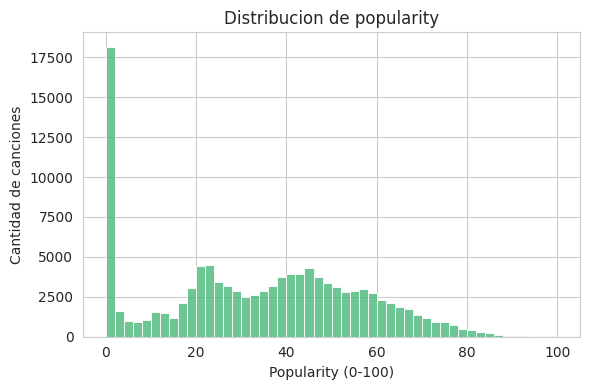

In [75]:
# 8. Distribucion de la variable objetivo 'popularity'
# Un solo grafico porque es la variable mas importante del proyecto, se analiza aparte
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df['popularity'], bins=50, color='mediumseagreen', ax=ax)
ax.set_title('Distribucion de popularity')
ax.set_xlabel('Popularity (0-100)')
ax.set_ylabel('Cantidad de canciones')
plt.tight_layout()
plt.show()

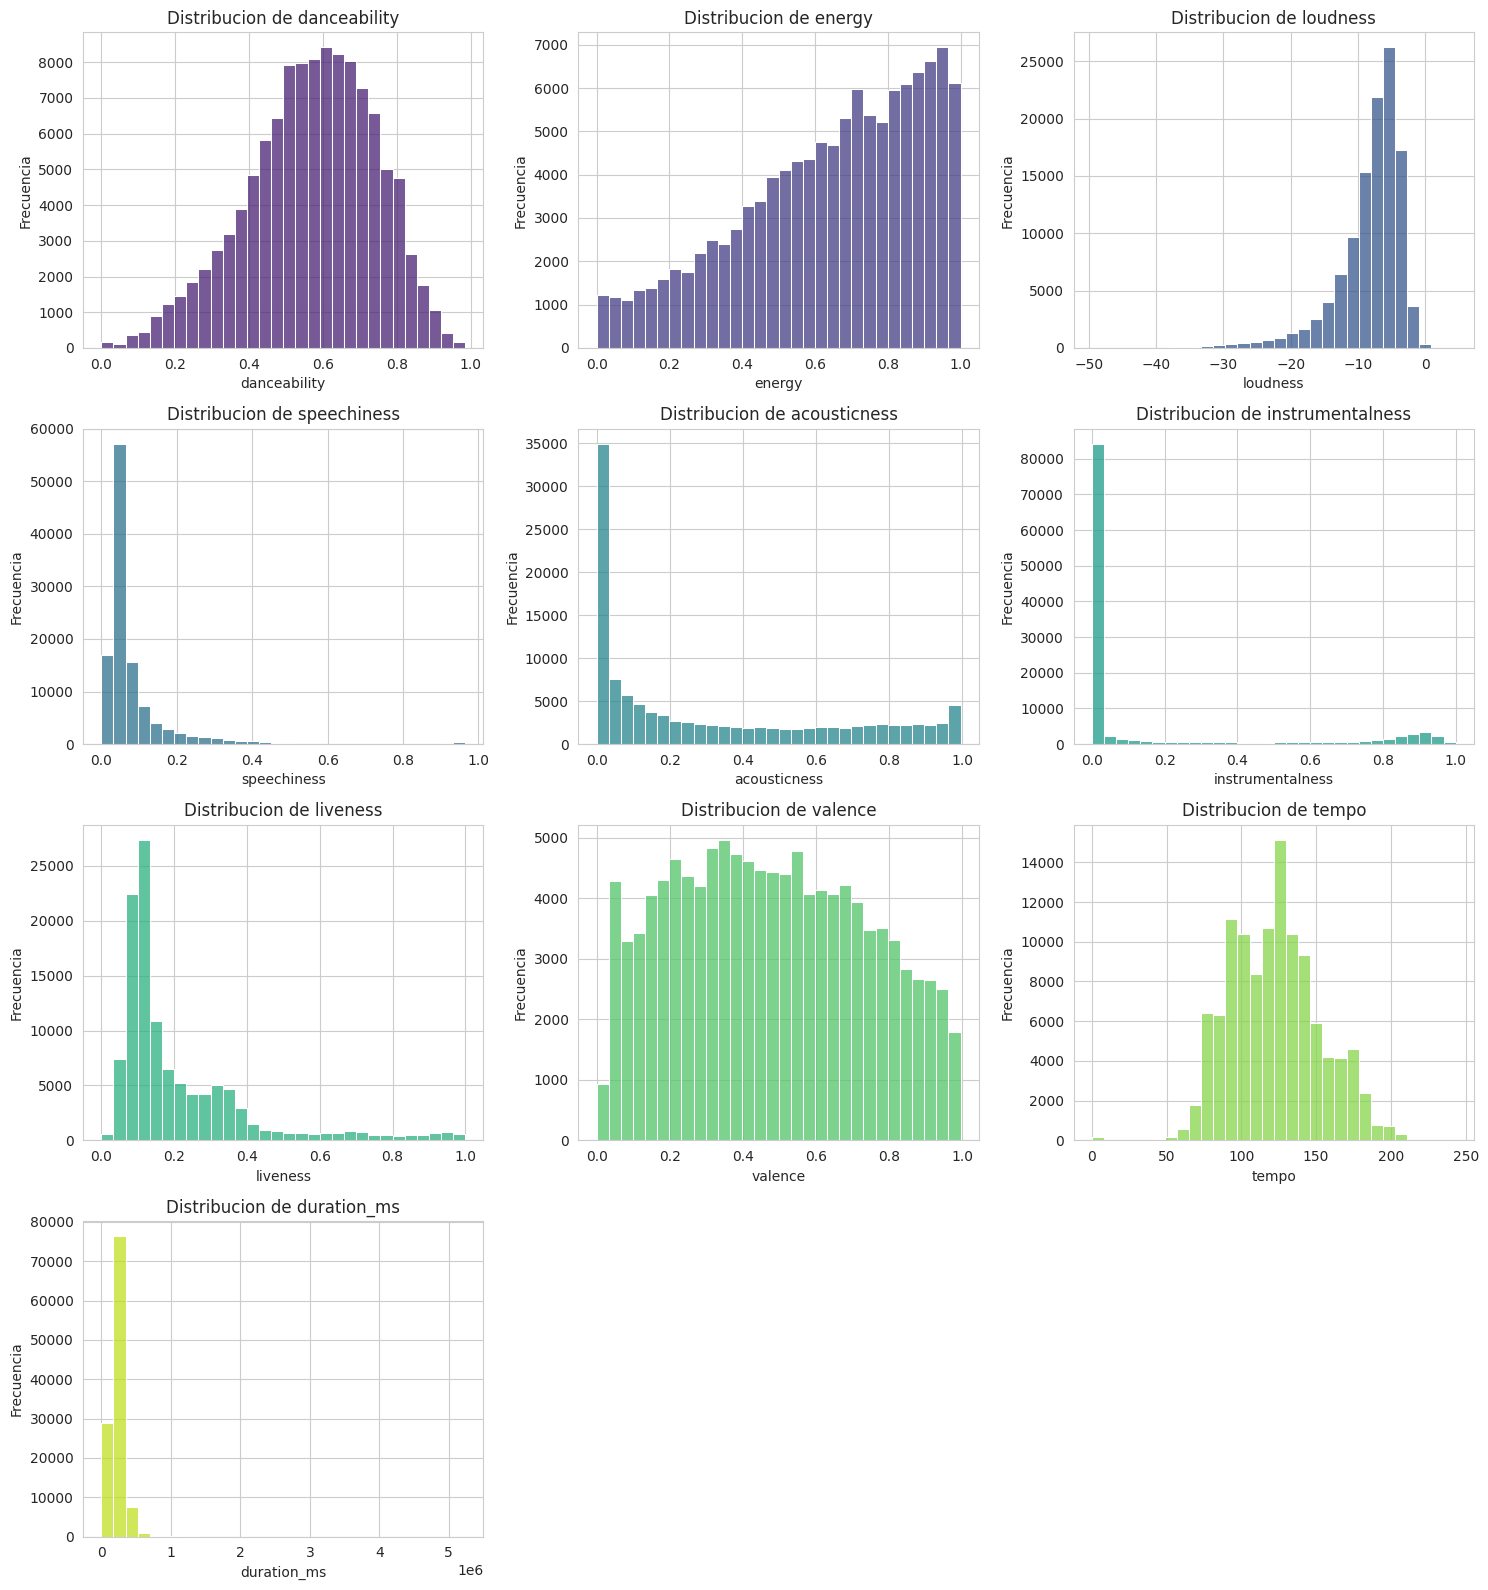

In [76]:
# 9. Distribucion de variables numericas de audio (features), maximo 3 graficos por fila
num_features = ['danceability', 'energy', 'loudness', 'speechiness',
                 'acousticness', 'instrumentalness', 'liveness',
                 'valence', 'tempo', 'duration_ms']

colors = sns.color_palette('viridis', len(num_features))

n_cols = 3
n_rows = -(-len(num_features) // n_cols)  # redondeo hacia arriba
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], bins=30, color=colors[i], ax=axes[i])
    axes[i].set_title(f'Distribucion de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Se ocultan los subplots sobrantes si num_features no es multiplo de 3
for j in range(len(num_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4207/2104410973.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='explicit', data=df, palette=['#4C72B0', '#C44E52'], ax=axes[0])
/tmp/ipykernel_4207/2104410973.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='mode', data=df, palette=['#8172B2', '#CCB974'], ax=axes[1])
/tmp/ipykernel_4207/2104410973.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='time_signature', data=df, palette='crest', ax=axes[2])


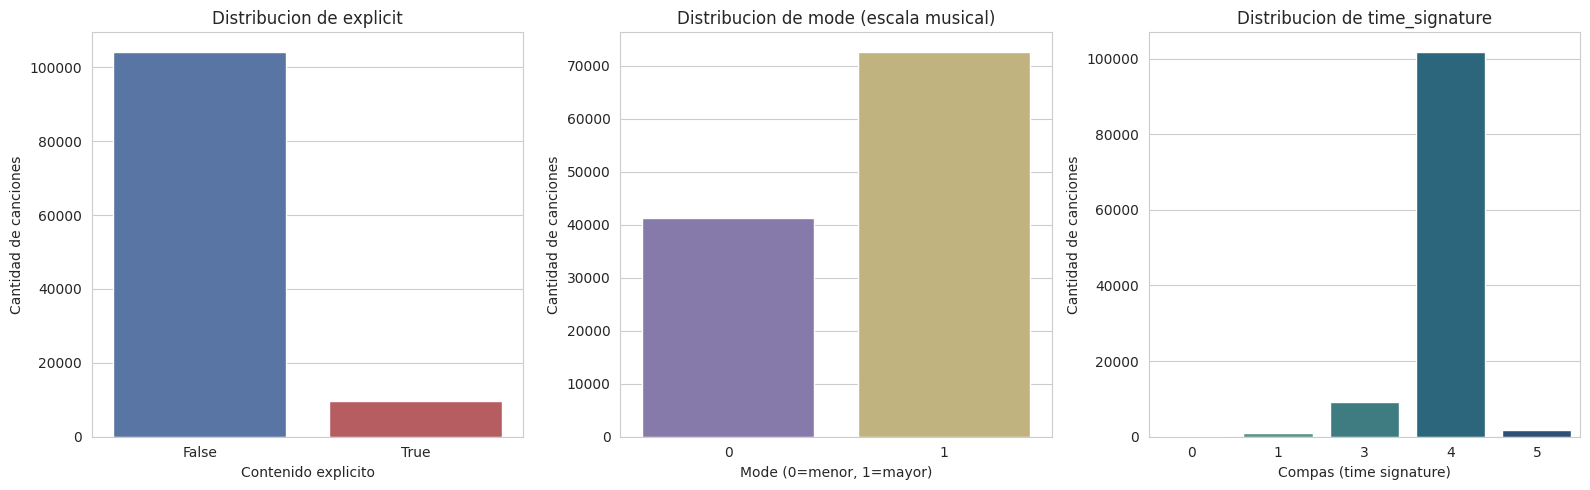

In [77]:
# 10. Distribucion de variables categoricas relevantes, maximo 3 graficos por fila
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# explicit: booleana, color segun contenido explicito o no
sns.countplot(x='explicit', data=df, palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Distribucion de explicit')
axes[0].set_xlabel('Contenido explicito')
axes[0].set_ylabel('Cantidad de canciones')

# mode: 0=menor, 1=mayor (variable musical, tratarla como categorica)
sns.countplot(x='mode', data=df, palette=['#8172B2', '#CCB974'], ax=axes[1])
axes[1].set_title('Distribucion de mode (escala musical)')
axes[1].set_xlabel('Mode (0=menor, 1=mayor)')
axes[1].set_ylabel('Cantidad de canciones')

# time_signature: compas musical
sns.countplot(x='time_signature', data=df, palette='crest', ax=axes[2])
axes[2].set_title('Distribucion de time_signature')
axes[2].set_xlabel('Compas (time signature)')
axes[2].set_ylabel('Cantidad de canciones')

plt.tight_layout()
plt.show()

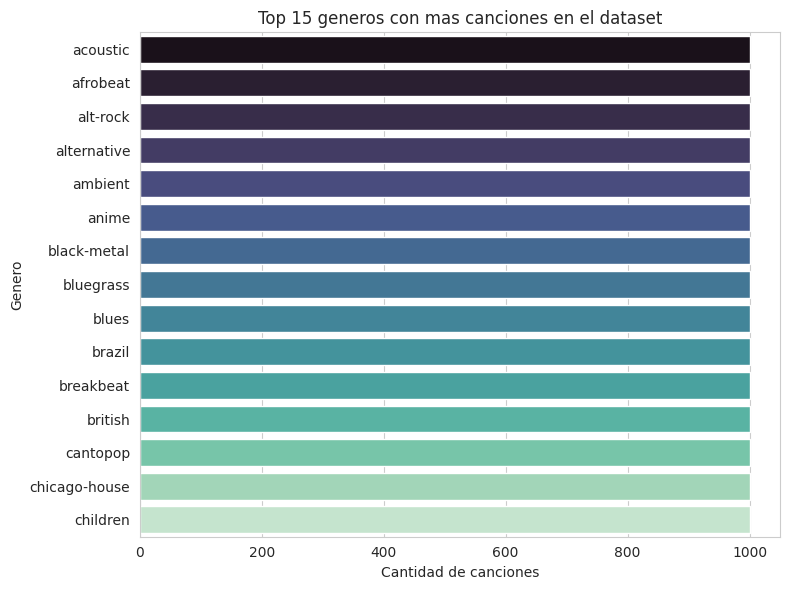

In [78]:
# 10.1 Distribucion de generos: al ser 114 categorias no se grafican todas, solo el top 15
plt.figure(figsize=(8, 6))
top_genres = df['track_genre'].value_counts().head(15)
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index,
            palette='mako', legend=False)
plt.title('Top 15 generos con mas canciones en el dataset')
plt.xlabel('Cantidad de canciones')
plt.ylabel('Genero')
plt.tight_layout()
plt.show()

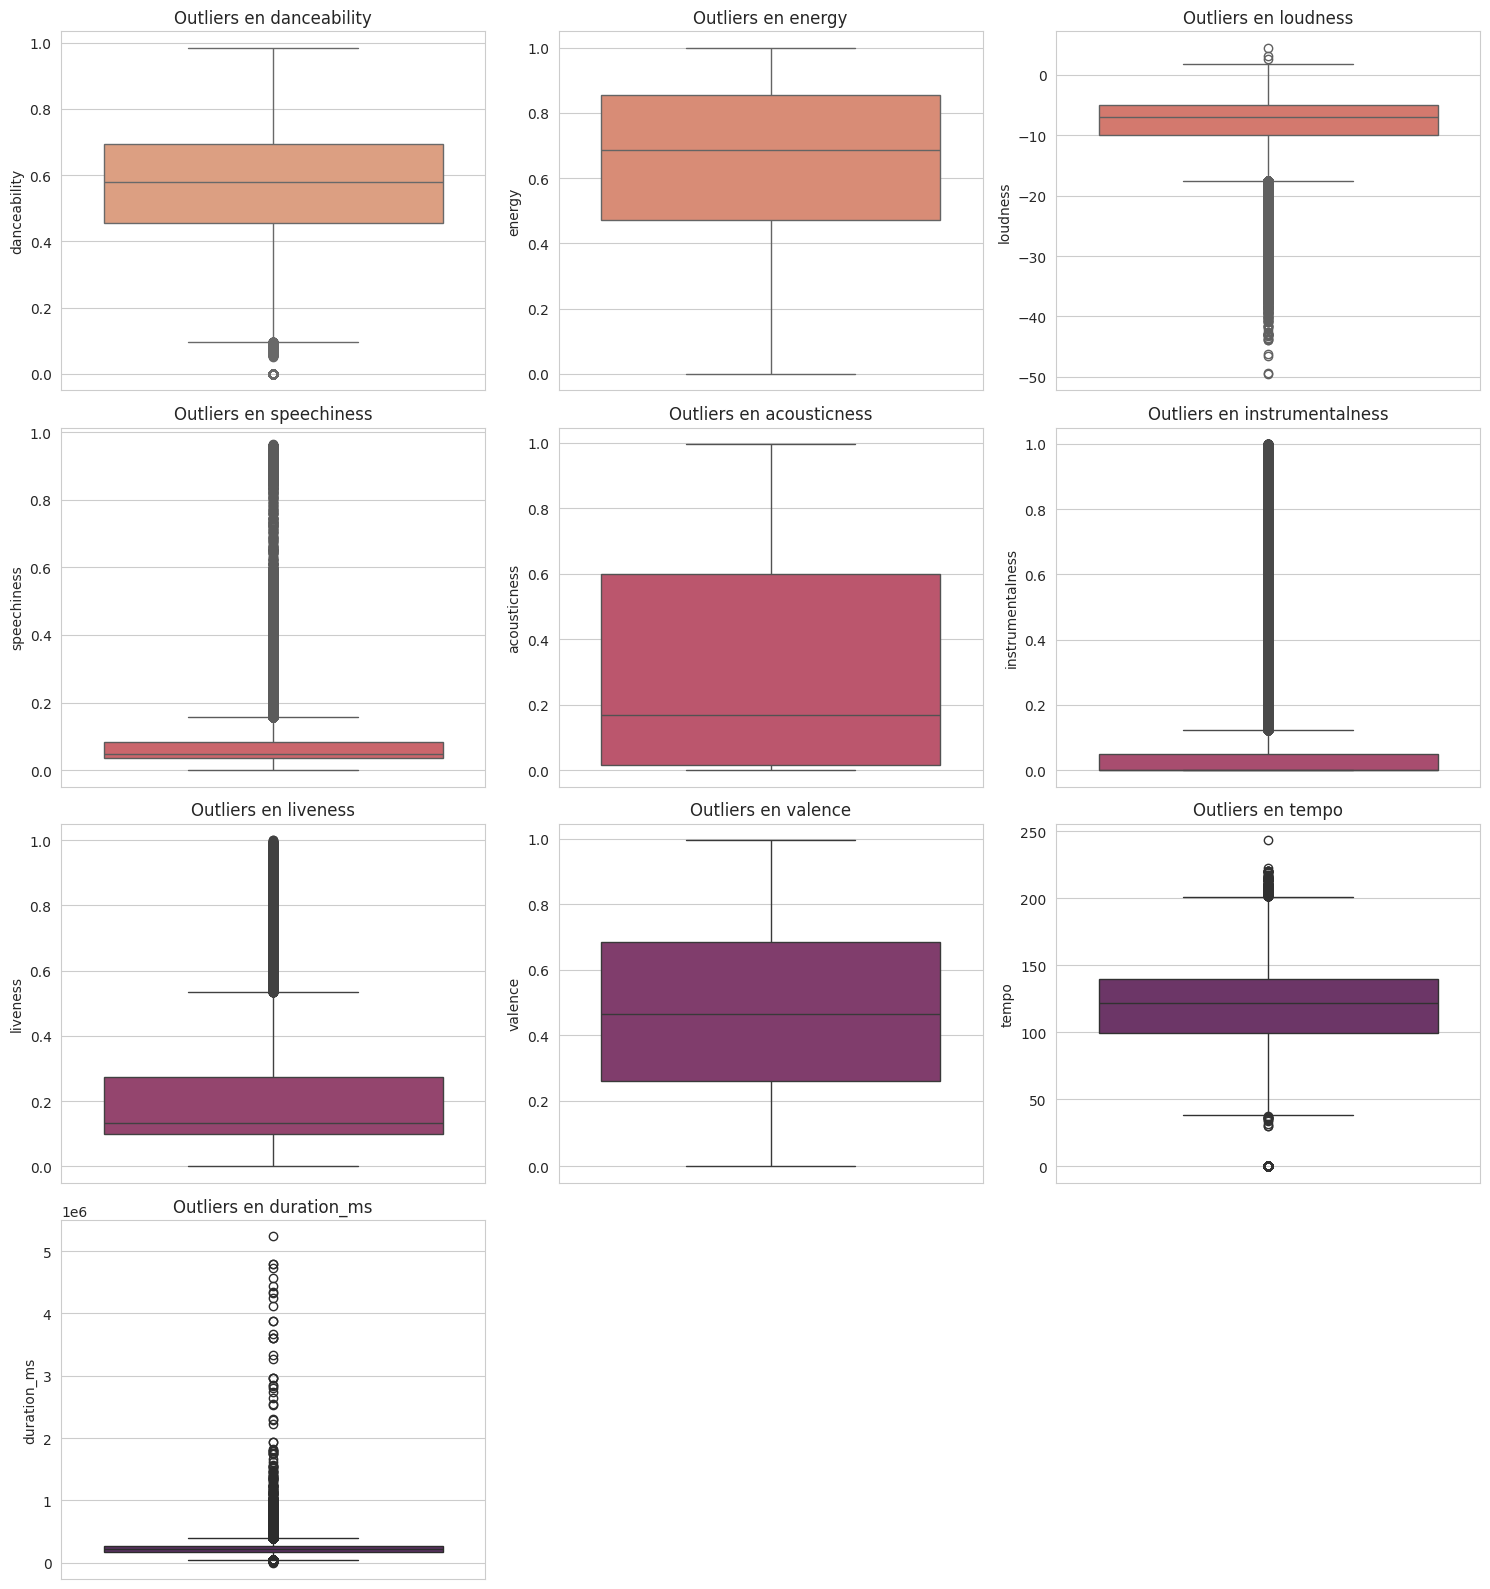

In [61]:
# 11. Deteccion de outliers en variables numericas con boxplot, maximo 3 graficos por fila
colors_box = sns.color_palette('flare', len(num_features))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], color=colors_box[i], ax=axes[i])
    axes[i].set_title(f'Outliers en {col}')
    axes[i].set_ylabel(col)

for j in range(len(num_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [62]:
# 11.1 Cuantificacion de outliers por columna usando el metodo IQR
def contar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return ((serie < lim_inf) | (serie > lim_sup)).sum()

outliers_resumen = {col: contar_outliers_iqr(df[col]) for col in num_features}
pd.Series(outliers_resumen, name='cantidad_outliers').sort_values(ascending=False)

,cantidad_outliers
instrumentalness,25246
speechiness,13211
liveness,8642
loudness,6173
duration_ms,5617
danceability,620
tempo,617
energy,0
acousticness,0
valence,0


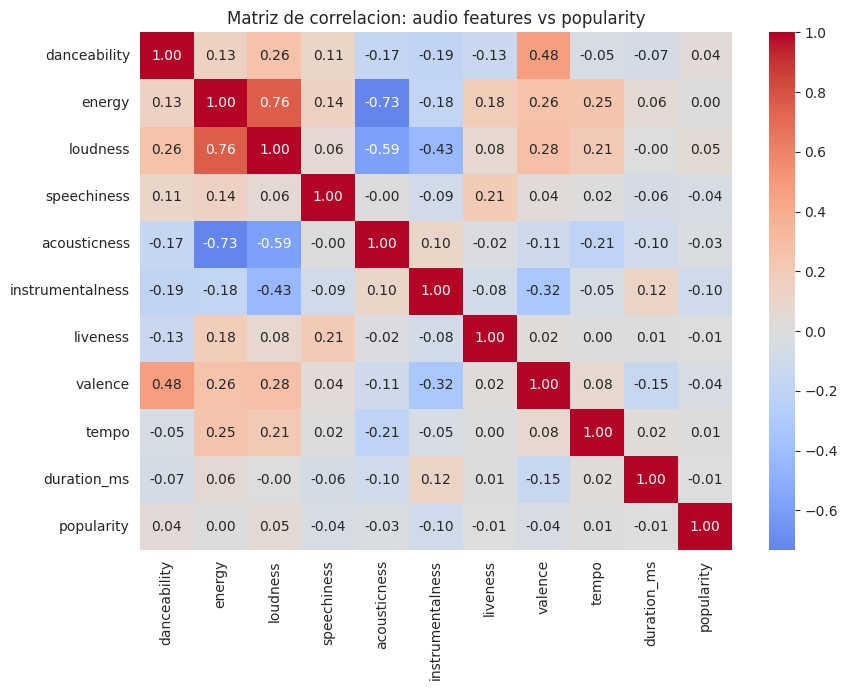

In [63]:
# 12. Correlacion entre variables numericas y popularity
plt.figure(figsize=(9, 7))
corr = df[num_features + ['popularity']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlacion: audio features vs popularity')
plt.tight_layout()
plt.show()

## Imputacion de valores nulos
Segun lo detectado en el punto 7, se define el metodo de imputacion por tipo de variable.

In [64]:
# 13. Imputacion de nulos segun el tipo de variable
# Columnas numericas con nulos: se imputan con la MEDIANA en vez de la media,
# porque el punto 11.1 mostro presencia de outliers en varias features de audio,
# y la mediana es robusta ante valores extremos (a diferencia de la media, que se desplaza con ellos).
num_nulls = df[num_features].isnull().sum()
num_nulls_cols = num_nulls[num_nulls > 0].index.tolist()

for col in num_nulls_cols:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"'{col}' imputado con mediana = {mediana:.3f}")

# Columnas categoricas con nulos: se imputan con la MODA (valor mas frecuente),
# porque no existe un promedio para texto/categorias, y la moda mantiene
# la distribucion original de las categorias sin introducir una clase artificial.
cat_nulls = df[cat_cols].isnull().sum()
cat_nulls_cols = cat_nulls[cat_nulls > 0].index.tolist()

for col in cat_nulls_cols:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)
    print(f"'{col}' imputado con moda = '{moda}'")

if not num_nulls_cols and not cat_nulls_cols:
    print("No se detectaron valores nulos en el dataset, no se requiere imputacion.")

'artists' imputado con moda = 'The Beatles'
'album_name' imputado con moda = 'Alternative Christmas 2022'
'track_name' imputado con moda = 'Run Rudolph Run'


In [65]:
# 13.1 Verificacion final: confirmar que ya no quedan nulos
df.isnull().sum().sum()

np.int64(0)